In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)

# Data Cleaning: Convert TotalCharges and drop customerID (not a feature)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn Rate: 26.54%


C:\Users\andry\AppData\Local\Temp\ipykernel_4696\3638753955.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


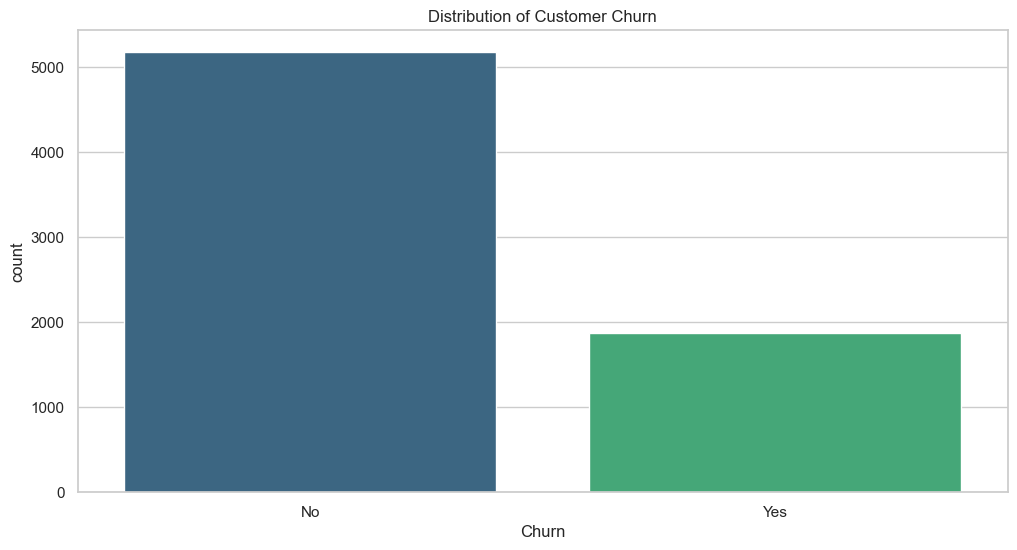

In [6]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_counts['Yes']:.2f}%")

sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

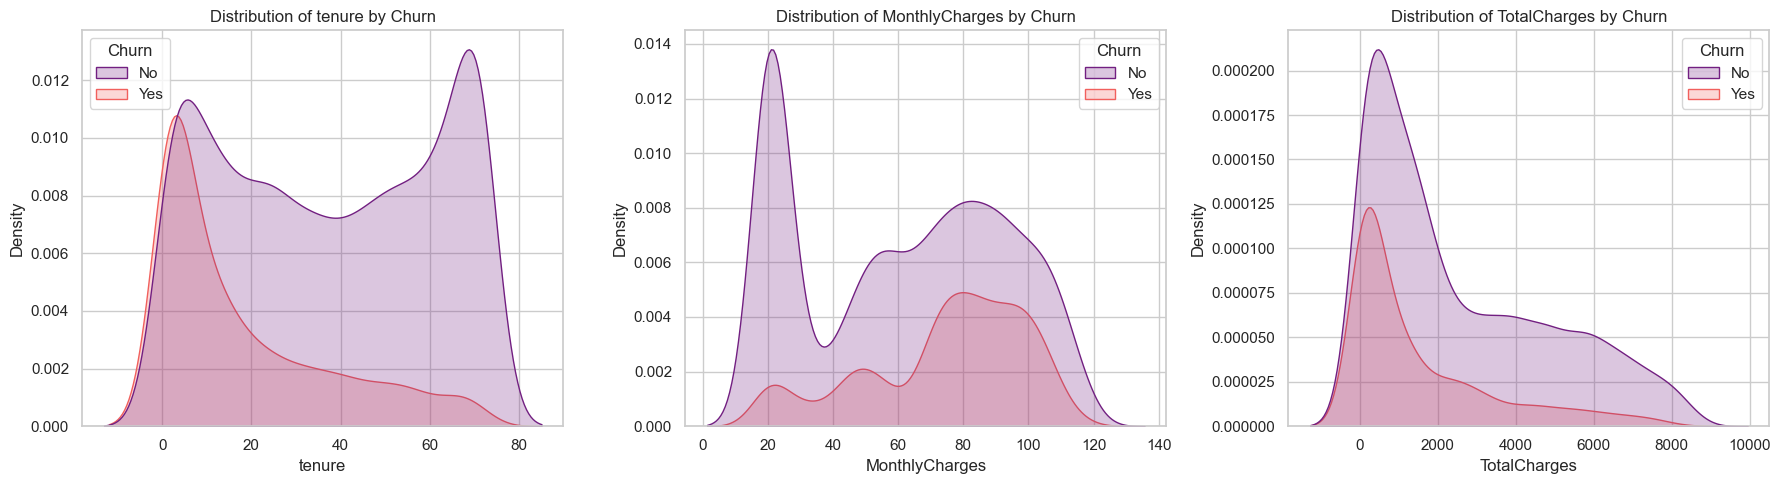

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='magma')
    axes[i].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()
plt.show()

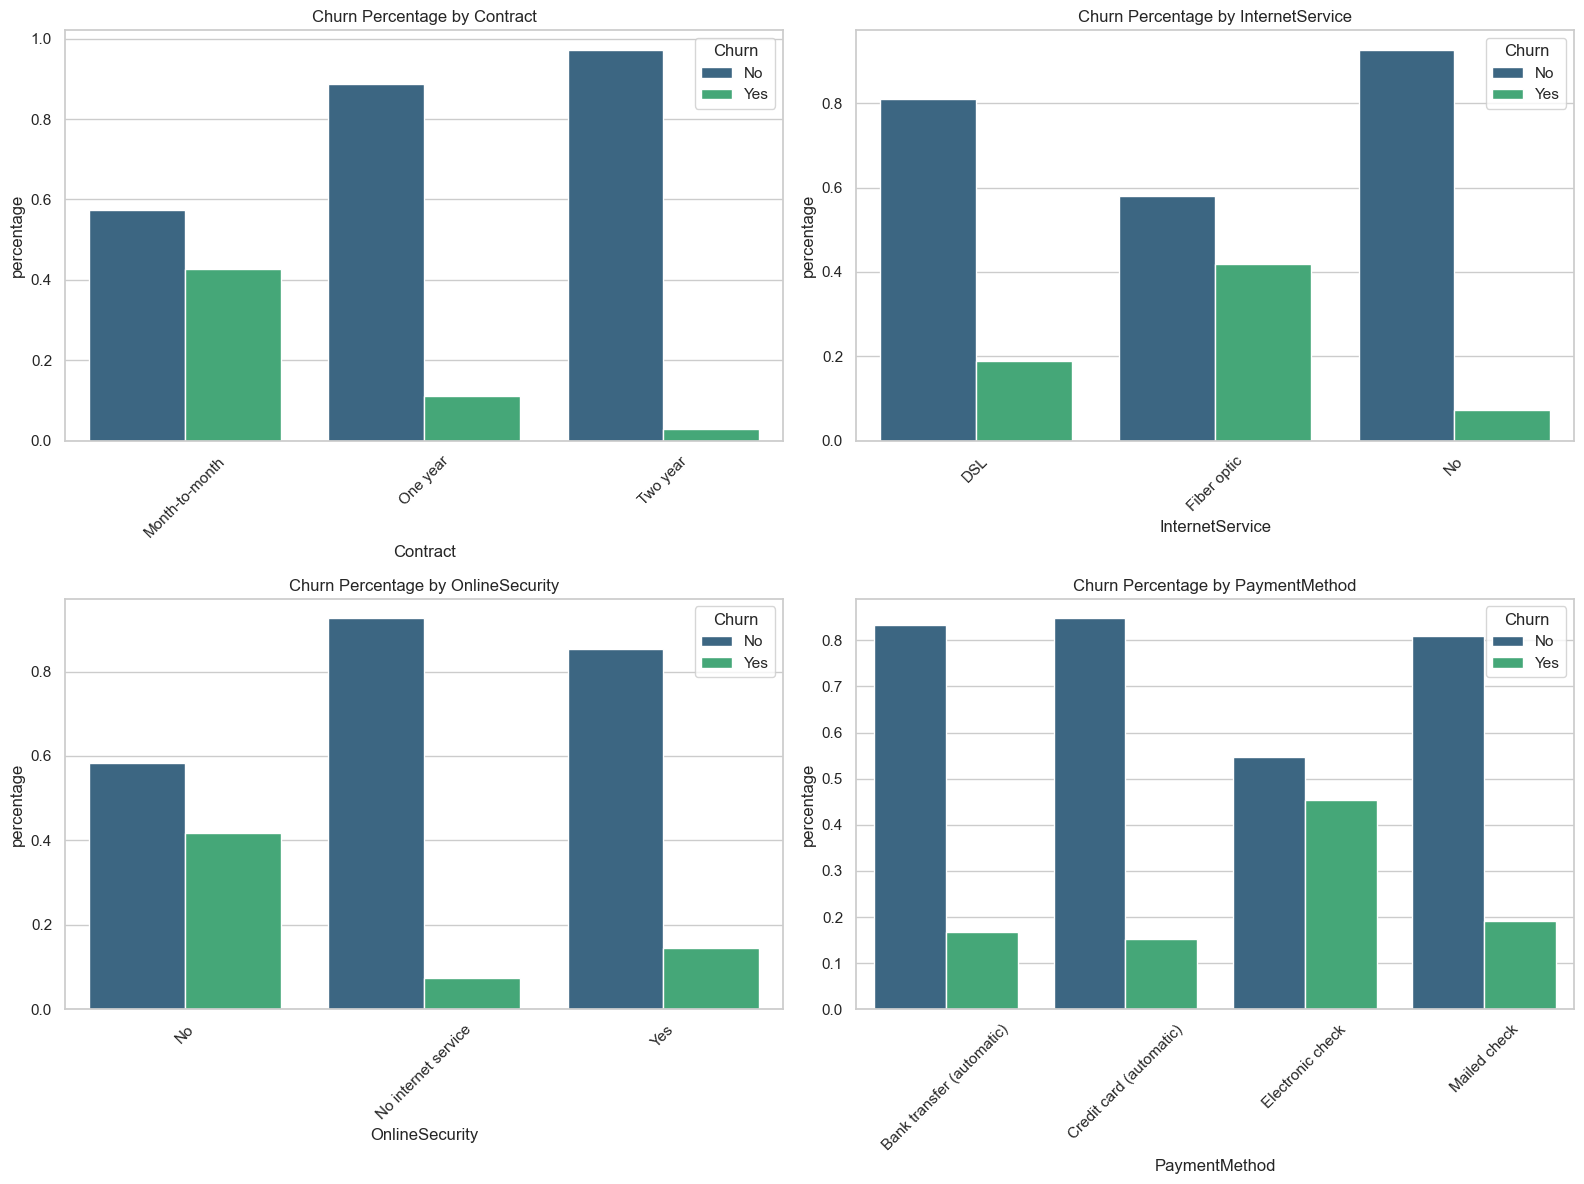

In [8]:
# List of categorical features to analyze
cat_features = ['Contract', 'InternetService', 'OnlineSecurity', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Calculate percentage of churn within each category
    prop_df = df.groupby(col)['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
    sns.barplot(data=prop_df, x=col, y='percentage', hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn Percentage by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()